In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #51daca; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #04335a">Stokes Equations </h3>
</div>

- Stokes flow, also named creeping flow or creeping motion, is a type of fluid flow where advective inertial <br>
forces are small compared with viscous forces. The Reynolds number is low, i.e. $\displaystyle \mathrm {Re} \ll 1$. <br>
This is a typical situation in flows where the fluid velocities are very slow, the viscosities are very large, <br>
or the length-scales of the flow are very small. Creeping flow was first studied to understand lubrication. <br>
In nature, this type of flow occurs in the swimming of microorganisms and sperm. In technology, it occurs <br>
in paint, MEMS devices, and in the flow of viscous polymers generally.

$$
\begin{cases}
-\nu \Delta u + \nabla p = 0
& \text{in } \Omega, \\[0.5em]

\nabla \cdot u = 0
& \text{in } \Omega, \\[0.5em]

u = g
& \text{on } \Gamma_D, \\[0.5em]

-p\,n + \nu (\nabla u)n = h
& \text{on } \Gamma_N.
\end{cases}
$$

- Find $(u,p) \in X \times Q$ such that:

$$
\begin{cases}
\displaystyle
\int_{\Omega} \nu \nabla u : \nabla v \, d\Omega
-
\int_{\Omega} p \, (\nabla \cdot v)\, d\Omega
=
\int_{\Gamma_N} h \cdot v \, d\Gamma
-
\int_{\Omega} \nu \nabla r_g : \nabla v \, d\Omega,
& \forall v \in X,
\\[1.2em]

\displaystyle
-\int_{\Omega} q \, (\nabla \cdot u)\, d\Omega
=
\int_{\Omega} q \, (\nabla \cdot r_g)\, d\Omega,
& \forall q \in Q.
\end{cases}
$$

<div align="center">
Where:

$$
\nabla u : \nabla v
=
\sum_{i,j}
\frac{\partial u_i}{\partial x_j}
\frac{\partial v_i}{\partial x_j}
$$

 - or if we use a simplified notation:

$$
\begin{array}{cc}
\displaystyle
d(v,w)
=
\int_{\Omega}
\nu \, \nabla v : \nabla w
\, d\Omega
&
\displaystyle
b(v,q)
=
-
\int_{\Omega}
q \, (\nabla \cdot v)
\, d\Omega
\\[1.5em]

\displaystyle
f_1(w)
=
\int_{\Gamma_N}
h \cdot w
\, d\Gamma
-
d(r_g,w)
&
\displaystyle
f_2(q)
=
-
b(r_g,q)
\end{array}
$$

- Find $(u,p)\in X \times Q$ such that:

$$
\begin{cases}
d(u,v) + b(v,p)
=
f_1(v),
& \forall v \in X,
\\[1em]

b(u,q)
=
f_2(q),
& \forall q \in Q.
\end{cases}
$$

<br>
<br>
<br>

$$
u_h(x,y)
=
\sum_{j=1}^{N_v}
U_j \phi_j(x,y),
\qquad
p_h(x,y)
=
\sum_{k=1}^{N_p}
P_k \psi_k(x,y)
$$

$$
d(v,w)
=
\int_{\Omega}
\nu \nabla v : \nabla w
\, d\Omega
=
\sum_{T}
\int_T
\nu \nabla v : \nabla w
\, dT
$$

$$
b(v,q)
=
-
\int_{\Omega}
q(\nabla \cdot v)
\, d\Omega
=
-
\sum_T
\int_T
q(\nabla \cdot v)
\, dT
$$

$$
\nabla v : \nabla w
=
\sum_{i,j}
\frac{\partial v_i}{\partial x_j}
\frac{\partial w_i}{\partial x_j}
$$

$$
A_{ij}^{(T)}
=
\int_T
\nu \nabla \phi_j \cdot \nabla \phi_i
\, dT
$$

$$
B_{ki}^{(T)}
=
-
\int_T
\psi_k
(\nabla \cdot \phi_i)
\, dT
$$

$$
\int_T
f(x,y)
\, dT
\approx
\sum_{q=1}^{N_q}
w_q
f(x_q,y_q)
\det(J)
$$

$$
\left[
\begin{array}{cc|c}
A & 0 & B_x^T \\
0 & A & B_y^T \\
\hline
B_x & B_y & 0
\end{array}
\right]
\begin{bmatrix}
\mathbf{U}_x \\
\mathbf{U}_y \\
\mathbf{P}
\end{bmatrix}
=
\begin{bmatrix}
\mathbf{F}_x \\
\mathbf{F}_y \\
\mathbf{0}
\end{bmatrix}
$$

---
Imports:

In [2]:
import numpy as np

from Utilities.fem_poisson import *
from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import mesh_df

---
### Mesh

We begin with the mesh construction and refinement:

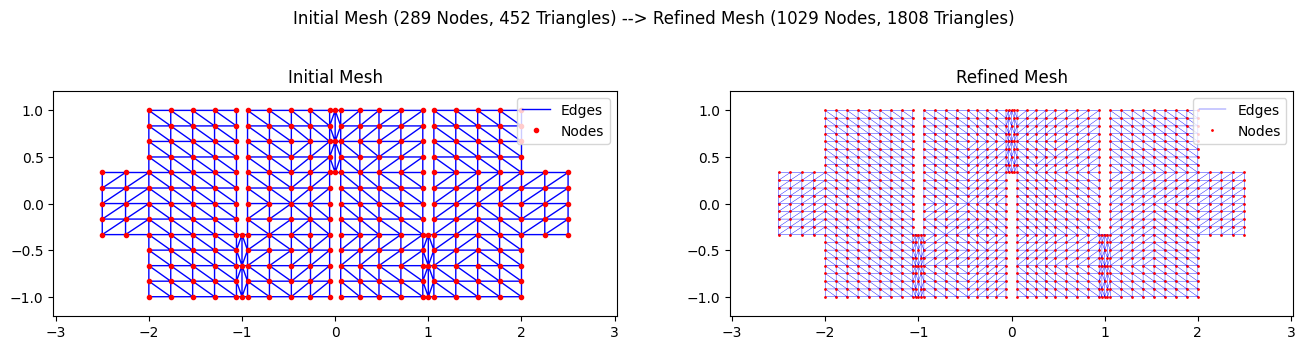

In [3]:
p, e, t = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_mesh_data.npz', num_of_refinements=1, 
                                      figsize=(16,4))

In [4]:
mesh_df(p, e, t, first_n_entries=13)

p is of shape: (1029, 2)
e is of shape: (2836, 3)
t is of shape: (1808, 7)


$P_1\text{-iso-}P_1$ Mesh is used for the Stokes Equations in this demonstration.

---


$$
\begin{aligned}
A^{loc}_{ij} &= \int_T \nu (\nabla \hat{\phi_j})^T \cdot J_T^{-1}J_T^{-T} \cdot \nabla \hat{\phi_i} |J_T| dx \\
&= \frac{\nu}{2|J_T|}\cdot  (\nabla \hat{\phi_j})^T \mathbb{Q} \nabla \hat{\phi_i}
\end{aligned}
$$

In [5]:
def calculate_velocity_A(p, t, kinematic_viscosity):
    """
    This is a matrix for the first integral in the Stokes Equations - The Stiffness Matrix A
    """

    Np = p.shape[0]
    Nt = t.shape[0]

    # we calculate all jacobians simultaneously           J = |x_2 - x_1   x_3 - x_1|
    #                                                         |y_2 - y_1   y_3 - y_1|

    jacobian = np.zeros(shape=(Nt, 2, 2))
    jacobian[:, 0, :] = p[t[:, 1]] - p[t[:, 0]] 
    jacobian[:, 1, :] = p[t[:, 2]] - p[t[:, 0]] 

    det_J = jacobian[:, 0, 0] * jacobian[:, 1, 1] - jacobian[:, 0, 1] * jacobian[:, 1, 0]

    # Cofactor multiplication matrix Q:                   Q = |(y_3 - y_1)^2 + (x_3 - x_1)^2                   (y_1 - y_2)(y_3 - y_1) + (x_2 - x_1)(x1 - x_3)|
    #                                                         |(y_1 - y_2)(y_3 - y_1) + (x_2 - x_1)(x1 - x_3)  (y_2 - y_1)^2 + (x_2 - x_1)^2                 |
    #
    #                                                     Q = Cof(J).T @ Cof(J)

    q11 = jacobian[:, 1, 1]**2 + jacobian[:, 0, 1]**2
    q12 = -(jacobian[:, 1, 0] * jacobian[:, 1, 1] + jacobian[:, 0, 0] * jacobian[:, 0, 1])
    q22 = jacobian[:, 1, 0]**2 + jacobian[:, 0, 0]**2

    Q_mat = np.zeros_like(jacobian)
    Q_mat[:, 0, 0] = q11
    Q_mat[:, 1, 0], Q_mat[:, 0, 1] = q12, q12
    Q_mat[:, 1, 1] = q22
    
    test_function_derivatives = np.array([[-1, -1],   # ф1 = 1 - s_1 - s_2
                                          [1, 0],     # ф2 = s_1
                                          [0, 1]])    # ф3 = s_2


    # We can now construct a local matrix A for each triangle:
    
    A_local = np.zeros(shape=(Nt, 3, 3))
    for i in range(3):
        for j in range(i, 3):

            grad_i = test_function_derivatives[i]
            grad_j = test_function_derivatives[j]

            val = np.einsum(
                'i, nij, j->n', 
                grad_j,
                Q_mat,
                grad_i
            )

            val *= kinematic_viscosity / (2 * det_J)

            A_local[:, i, j] = val
            A_local[:, j, i] = val

    # INVESTIGATE:
    # A_local = np.einsum('mi,tkj,nj->tmn', test_function_derivatives, Q_mat, test_function_derivatives)
    # A_local *= (kinematic_viscosity / (2.0 * np.abs(det_J)))[:, None, None]

    rowidx = np.einsum("ni,j->nij", t[:,0:3], [1,1,1])
    colidx = np.einsum("nj,i->nij", t[:,0:3], [1,1,1])
    
    # Return corresponding csc_matrix
    return sparse.csc_matrix((np.ravel(A_local),(np.ravel(rowidx),np.ravel(colidx))),shape=(Np,Np))

In [6]:
matrix_A = calculate_velocity_A(p, t, 1)

In [7]:
def calculate_pressure_B(p, t):
    
    return None